# Laboratorio 8 — Cliff Walking con Q-learning
Implementación simple y directa de Q-learning:
- **Tabla Q** para guardar valores
- **Exploración → Explotación** (epsilon decay)
- **Evalúa porcentaje de éxito**


## Requisitos
```bash
pip install gymnasium matplotlib numpy
```

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import os

np.random.seed(42)


In [27]:
# Crear entorno
env = gym.make('CliffWalking-v1')
print(f'Estados: {env.observation_space.n}')
print(f'Acciones: {env.action_space.n} (0:arriba, 1:derecha, 2:abajo, 3:izquierda)')


Estados: 48
Acciones: 4 (0:arriba, 1:derecha, 2:abajo, 3:izquierda)


## PASO 1: Entrenamiento con Q-learning


In [28]:
n_estados = env.observation_space.n
n_acciones = env.action_space.n
Q = np.zeros((n_estados, n_acciones))

episodios = 1500
alpha = 0.2
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995

historial_recompensas = []


for ep in range(episodios):
    estado, _ = env.reset()
    recompensa_total = 0
    
    for paso in range(200):
        # Epsilon-greedy
        if np.random.random() < epsilon:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(Q[estado])
        
        nuevo_estado, recompensa, done, truncated, _ = env.step(accion)
        
        Q[estado, accion] += alpha * (recompensa + gamma * np.max(Q[nuevo_estado]) - Q[estado, accion])
        
        estado = nuevo_estado
        recompensa_total += recompensa
        
        if done or truncated:
            break
    
    historial_recompensas.append(recompensa_total)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    if (ep + 1) % 200 == 0:
        media = np.mean(historial_recompensas[-100:])
        print(f"Episodio {ep+1}/{episodios} | Recompensa media: {media:.1f} | Epsilon: {epsilon:.2f}")


np.save('q_table.npy', Q)

Episodio 200/1500 | Recompensa media: -362.3 | Epsilon: 0.37
Episodio 400/1500 | Recompensa media: -94.8 | Epsilon: 0.13
Episodio 600/1500 | Recompensa media: -32.8 | Epsilon: 0.05
Episodio 800/1500 | Recompensa media: -20.6 | Epsilon: 0.02
Episodio 1000/1500 | Recompensa media: -17.3 | Epsilon: 0.01
Episodio 1200/1500 | Recompensa media: -16.3 | Epsilon: 0.01
Episodio 1400/1500 | Recompensa media: -16.4 | Epsilon: 0.01


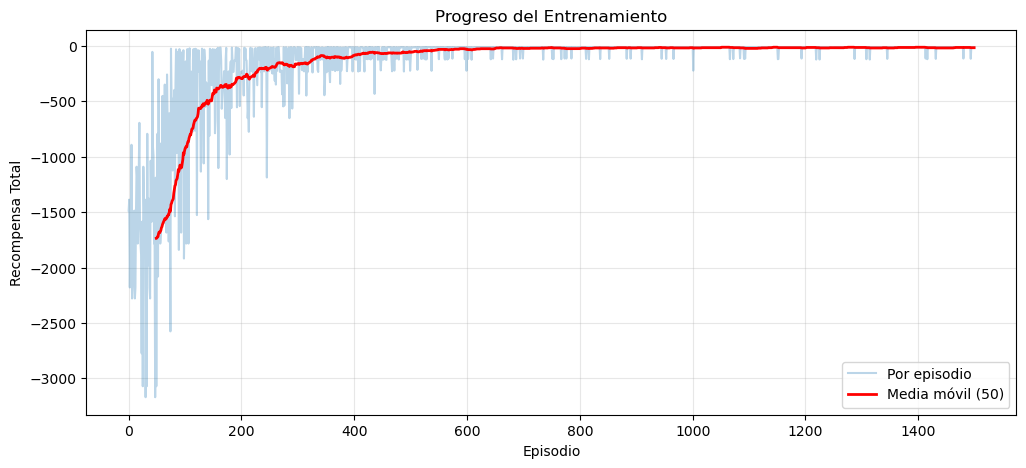

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(historial_recompensas, alpha=0.3, label='Por episodio')
ventana = 50
media_movil = np.convolve(historial_recompensas, np.ones(ventana)/ventana, mode='valid')
plt.plot(range(ventana-1, len(historial_recompensas)), media_movil, 'r-', linewidth=2, label=f'Media móvil ({ventana})')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Total')
plt.title('Progreso del Entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## PASO 2: Evaluación del modelo


In [30]:
exitos = 0
n_pruebas = 100

print("🧪 EVALUANDO MODELO...\n")

for prueba in range(n_pruebas):
    estado, _ = env.reset()
    pasos = 0
    
    for paso in range(200):
        accion = np.argmax(Q[estado])
        estado, recompensa, done, truncated, _ = env.step(accion)
        pasos += 1
        
        if done or truncated:
            if recompensa > -50:
                exitos += 1
            if prueba < 3:
                print(f"Prueba {prueba+1}: {'✓ Éxito' if recompensa > -50 else '✗ Falló'} ({pasos} pasos)")
            break

porcentaje_exito = (exitos / n_pruebas) * 100

print(f"📊 RESULTADOS FINALES")
print(f"✓ Porcentaje de éxito: {porcentaje_exito:.1f}%")
print(f"✓ Pruebas exitosas: {exitos}/{n_pruebas}")


🧪 EVALUANDO MODELO...

Prueba 1: ✓ Éxito (13 pasos)
Prueba 2: ✓ Éxito (13 pasos)
Prueba 3: ✓ Éxito (13 pasos)
📊 RESULTADOS FINALES
✓ Porcentaje de éxito: 100.0%
✓ Pruebas exitosas: 100/100


## PASO 3: Visualizar política aprendida


In [31]:
acciones_simbolos = {0: '↑', 1: '→', 2: '↓', 3: '←'}
politica = np.argmax(Q, axis=1)

for fila in range(4):
    linea = ""
    for col in range(12):
        estado = fila * 12 + col
        accion = politica[estado]
        linea += f" {acciones_simbolos[accion]} "
    print(linea)

print("\nS = inicio (abajo izquierda)")
print("G = meta (abajo derecha)")
print("C = acantilado (entre S y G)")


 →  →  →  →  →  →  →  →  →  ↓  →  ↓ 
 ↓  ↓  →  →  →  →  →  →  ↓  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑  ↑ 

S = inicio (abajo izquierda)
G = meta (abajo derecha)
C = acantilado (entre S y G)


## PASO 4: Cargar modelo guardado


In [32]:
Q_guardado = np.load('q_table.npy')
print("Modelo cargado desde: q_table.npy\n")

# Probarlo 5 veces
print("Probando modelo cargado:\n")
for i in range(5):
    estado, _ = env.reset()
    pasos = 0
    for paso in range(200):
        accion = np.argmax(Q_guardado[estado])
        estado, recompensa, done, truncated, _ = env.step(accion)
        pasos += 1
        if done or truncated:
            print(f"Ejecución {i+1}: {'✓ Éxito' if recompensa > -50 else '✗ Falló'} ({pasos} pasos)")
            break


Modelo cargado desde: q_table.npy

Probando modelo cargado:

Ejecución 1: ✓ Éxito (13 pasos)
Ejecución 2: ✓ Éxito (13 pasos)
Ejecución 3: ✓ Éxito (13 pasos)
Ejecución 4: ✓ Éxito (13 pasos)
Ejecución 5: ✓ Éxito (13 pasos)


## PASO 5: Demostración visual


In [33]:
import time

env_visual = gym.make('CliffWalking-v1', render_mode='human')
estado, _ = env_visual.reset()

for paso in range(200):
    accion = np.argmax(Q[estado])
    estado, recompensa, done, truncated, _ = env_visual.step(accion)
    time.sleep(0.2)
    
    if done or truncated:
        print(f"✓ Completado en {paso+1} pasos")
        break

env_visual.close()


✓ Completado en 13 pasos
